In [1]:
import math
import random
from dataclasses import dataclass, field, fields
from itertools import count
from statistics import mean
from typing import Callable, Collection, Generic, Sequence, TypeVar, cast

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import data.cmudict as cmudict
from state_merging.algorithms.ostia import ostia
from state_merging.automata.SFST import SFST
from state_merging.collections.dense_int_dict import DenseIntDict
from state_merging.collections.dense_int_set import DenseIntSet
from state_merging.operations.learner import MergeResults

T = TypeVar('T')
T_ = TypeVar('T_')

random.seed(42)

In [2]:
@dataclass
class Results(Generic[T]):
    sample_count: T = field()
    sample_input_size: T = field()
    ptt_state_count: T = field()
    merged_state_count: T = field()
    state_compression: T = field()
    build_ptt_time: T = field()
    merge_states_time: T = field()

    @classmethod
    def from_merge_results(cls, merge_results: MergeResults) -> 'Results[float]':
        return Results(
            sample_count=merge_results.sample_count,
            sample_input_size=merge_results.sample_input_size,
            ptt_state_count=merge_results.ptt_state_count,
            merged_state_count=merge_results.merged_state_count,
            state_compression=1 - merge_results.merged_state_count/merge_results.ptt_state_count,
            build_ptt_time=merge_results.build_ptt_time,
            merge_states_time=merge_results.merge_states_time
        )

    @classmethod
    def map(cls, fun: Callable[[T], T_], results: 'Results[T]') -> 'Results[T_]':
        return cls(**{
            f.name: fun(getattr(results, f.name))
            for f in fields(cls)
        }) # type: ignore

    @classmethod
    def collect(cls, all_results: Collection['Results[T]']) -> 'Results[list[T]]':
        return cls(**{
            f.name: [getattr(results, f.name) for results in all_results]
            for f in fields(cls)
        }) # type: ignore

    @classmethod
    def mean(cls, all_results: Collection['Results[float]']) -> 'Results[float]':
        return Results.map(mean, Results.collect(all_results)) # type: ignore

In [3]:
input_set: set[str] = cmudict.make_input_set()
output_set: set[str] = cmudict.make_output_set()
dataset: list[tuple[str, list[str]]] = list(cmudict.make_deterministic_sample())

print(
    f"loaded {len(dataset)} samples from the CMU Pronouncing Dictionary, e.g.:",
    random.choice(dataset)
)

print(f"input alphabet:", input_set)
print(f"output alphabet:", output_set)

loaded 126052 samples from the CMU Pronouncing Dictionary, e.g.: ('parmelee', ['P', 'AA1', 'R', 'M', 'IH0', 'L', 'IY0'])
input alphabet: {'e', 'x', 's', 'd', 'k', '.', "'", 'n', 'u', 'a', 'o', 'q', 'w', 'v', 'p', 'z', 't', 'c', 'y', 'f', 'r', 'h', 'b', 'l', 'm', '-', 'g', 'i', 'j'}
output alphabet: {'ER0', 'OW2', 'AW0', 'OW0', 'IH2', 'AY2', 'AH1', 'L', 'SH', 'EH1', 'IY1', 'AW2', 'UW0', 'AH0', 'AW1', 'P', 'OW1', 'EY0', 'IH1', 'B', 'AA0', 'Z', 'V', 'G', 'JH', 'AH2', 'OY1', 'AO2', 'IY2', 'N', 'NG', 'AE0', 'AA2', 'AE1', 'AE2', 'OY2', 'S', 'F', 'UH1', 'AY0', 'EY1', 'AO1', 'AO0', 'TH', 'ER2', 'UH0', 'OY0', 'EH0', 'K', 'W', 'IY0', 'EH2', 'Y', 'UW1', 'T', 'CH', 'DH', 'IH0', 'AY1', 'UH2', 'D', 'AA1', 'ZH', 'R', 'EY2', 'ER1', 'UW2', 'HH', 'M'}


In [4]:
iterations: int = 3
target_sample_sizes: list[int] = [int(10 ** (i / 4 + 2)) for i in range(8)]

print(
    f"to run {iterations} iterations of OSTIA with randomized merge order",
    f"on random samples of size {target_sample_sizes}"
)

to run 3 iterations of OSTIA with randomized merge order on random samples of size [100, 177, 316, 562, 1000, 1778, 3162, 5623]


In [5]:
mean_results_per_config: list[Results[float]] = []
mean_results_per_config_custom_dict: list[Results[float]] = []

for k in target_sample_sizes:
    print(f"running with sample size {k}")

    results_per_iter: list[Results[float]] = []
    results_per_iter_custom_dict: list[Results[float]] = []

    for i in range(iterations):
        print(i, end=' ')

        fst: SFST[int, str, Sequence[str]]
        fst, results = ostia(
            input_set=input_set,
            dataset=random.sample(dataset, k=k),
            epsilon=[],
            concat=lambda v1, v2: cast(list[str], v1) + cast(list[str], v2),
            choose_transition=lambda _, trs: random.choice(list(trs)),
            search_iter=lambda _, qs: random.sample(list(qs), k=len(qs)),
            empty_fst_state_set=set(),
            empty_transition_mapping={},
            empty_final_output_mapping={},
            make_empty_visited_state_set=lambda _: set(),
            make_default_populated_mapping=lambda qs: {q: [] for q in qs},
            state_supply=count()
        )

        _, results_custom_dict = ostia(
            input_set=input_set,
            dataset=random.sample(dataset, k=k),
            epsilon=[],
            concat=lambda v1, v2: cast(list[str], v1) + cast(list[str], v2),
            choose_transition=lambda _, trs: random.choice(list(trs)),
            search_iter=lambda _, qs: random.sample(list(qs), k=len(qs)),
            empty_fst_state_set=DenseIntSet(),
            empty_transition_mapping={},
            empty_final_output_mapping=DenseIntDict(),
            make_empty_visited_state_set=lambda qs: DenseIntSet(size=len(qs)),
            make_default_populated_mapping=lambda qs: DenseIntDict(size=len(qs), init=list),
            state_supply=count()
        )

        results_per_iter.append(Results.from_merge_results(results))
        results_per_iter_custom_dict.append(Results.from_merge_results(results_custom_dict))

    mean_results_per_config.append(Results.mean(results_per_iter))
    mean_results_per_config_custom_dict.append(Results.mean(results_per_iter_custom_dict))

    print()

print("done")

running with sample size 100
0 1 2 
running with sample size 177
0 1 2 
running with sample size 316
0 1 2 
running with sample size 562
0 1 2 
running with sample size 1000
0 1 2 
running with sample size 1778
0 1 2 
running with sample size 3162
0 1 2 
running with sample size 5623
0 1 2 
done


In [6]:
r: Results[list[float]] = Results.collect(mean_results_per_config) # type: ignore
rcd: Results[list[float]] = Results.collect(mean_results_per_config_custom_dict) # type: ignore
rs: list[Results[list[float]]] = [r, rcd]

alpha = 0.3
y_range_pad = 1.1

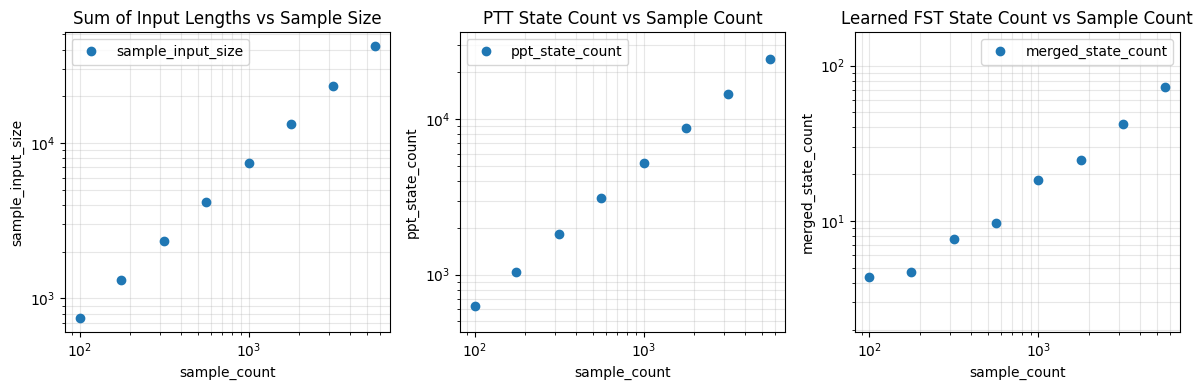

In [7]:
# type: ignore

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

y_log_datasets = [
    [math.log10(e) for e in r.sample_input_size],
    [math.log10(e) for e in r.ptt_state_count],
    [math.log10(e) for e in r.merged_state_count]
]

y_log_midpoints = [max(d)/2 + min(d)/2 for d in y_log_datasets]
y_log_ranges = [max(d) - min(d) for d in y_log_datasets]
y_log_range = max(y_log_ranges) * y_range_pad

axes[0].loglog(r.sample_count, r.sample_input_size, 'o', label='sample_input_size')
axes[0].set_title('Sum of Input Lengths vs Sample Size')
axes[0].set_xlabel('sample_count')
axes[0].set_ylabel('sample_input_size')

axes[1].loglog(r.sample_count, r.ptt_state_count, 'o', label='ppt_state_count')
axes[1].set_title('PTT State Count vs Sample Count')
axes[1].set_xlabel('sample_count')
axes[1].set_ylabel('ppt_state_count')

axes[2].loglog(r.sample_count, r.merged_state_count, 'o', label='merged_state_count')
axes[2].set_title('Learned FST State Count vs Sample Count')
axes[2].set_xlabel('sample_count')
axes[2].set_ylabel('merged_state_count')

for i in [0, 1, 2]:
    axes[i].set_ylim(
        10**(y_log_midpoints[i] - y_log_range/2),
        10**(y_log_midpoints[i] + y_log_range/2)
    )

    axes[i].grid(True, which='both', alpha=alpha)
    axes[i].legend()

plt.tight_layout()
plt.show()

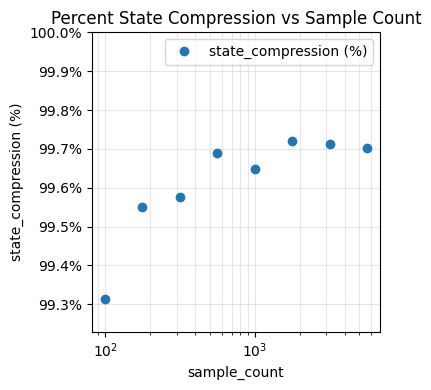

In [8]:
# type: ignore

fig, axes = plt.subplots(1, 1, figsize=(4, 4))

axes.semilogx(r.sample_count, [100 * e for e in r.state_compression], 'o', label='state_compression (%)')
axes.set_title('Percent State Compression vs Sample Count')
axes.set_xlabel('sample_count')
axes.set_ylabel('state_compression (%)')
axes.set_ylim(100 * (2*mean(r.state_compression) - 1), 100)
axes.yaxis.set_major_formatter(PercentFormatter(decimals=1))
axes.grid(True, which='both', alpha=alpha)
axes.legend()

plt.tight_layout()
plt.show()

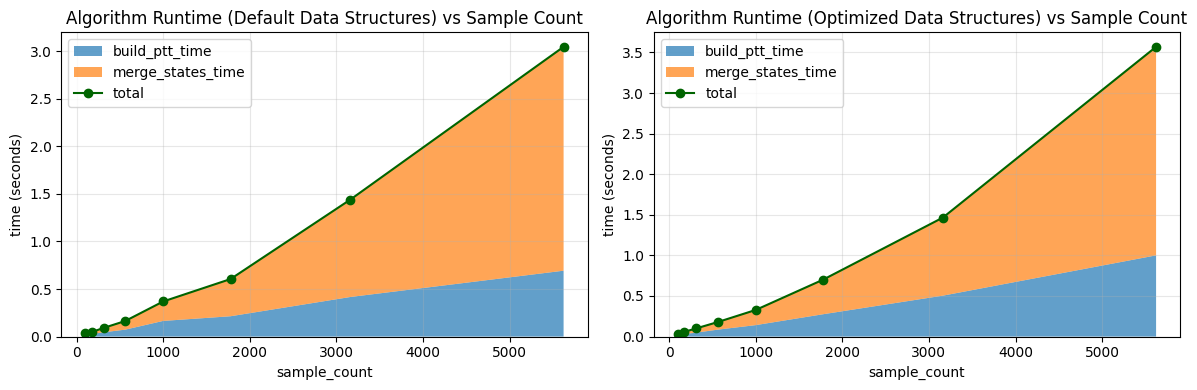

In [9]:
# type: ignore

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

titles = [
    'Algorithm Runtime (Default Data Structures) vs Sample Count',
    'Algorithm Runtime (Optimized Data Structures) vs Sample Count'
]

for i in range(len(rs)):

    axes[i].stackplot(
        rs[i].sample_count,
        rs[i].build_ptt_time,
        rs[i].merge_states_time,
        labels=['build_ptt_time', 'merge_states_time'],
        alpha=0.7
    )

    total_time = [
        b + m
        for b, m in zip(rs[i].build_ptt_time, rs[i].merge_states_time)
    ]

    axes[i].plot(r.sample_count, total_time, 'o-', color='darkgreen', label='total')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('sample_count')
    axes[i].set_ylabel('time (seconds)')
    axes[i].grid(True, which='both', alpha=alpha)
    axes[i].legend()

plt.tight_layout()
plt.show()